# Read Beta spectrum

In [1]:
pip install TDCRPy==2.19.2

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tdcrpy as td
import matplotlib.pyplot as plt
import numpy as np

In [3]:
radionuclide = "Tc-99"
mode = "beta-" # 'beta-' or 'beta+'
level = 'tot' # 0,1,2,3 .... or 'tot'

## Get information about the BetaShape version

In [4]:
print(td.TDCR_model_lib.readBetaShapeInfo(radionuclide,mode,level))

-Beta Spectrum (theory) from Fig.9 in
 https://arxiv.org/pdf/2309.14014-


## Read the energy spectrum tabulated from BetaShape

Text(0, 0.5, '$p(E)$ /(keV$^{-1}$)')

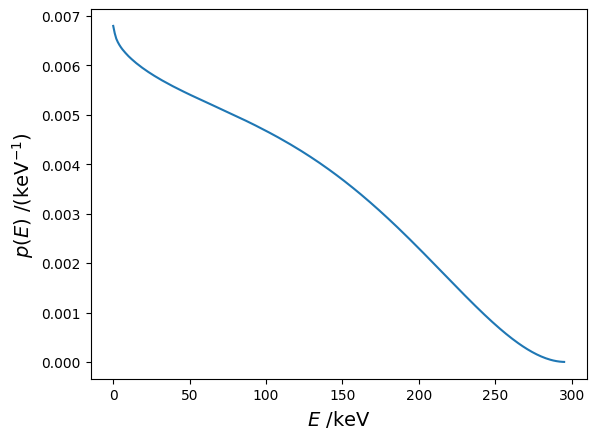

In [5]:
energy, probability = td.TDCR_model_lib.readBetaShape(radionuclide,mode,level)

plt.figure("Energy spectrum")
plt.clf()
plt.plot(energy[:-1], probability)
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'$p(E)$ /(keV$^{-1}$)', fontsize=14)

## Read the deposited energy spectrum

This spectrum is built by TDCRPy (function `buildBetaSpectra`) to be used for the analytical TDCR model.
This function is available for: H-3, C-14, S-35, Ca-45, Ni-63, Sr-89, Sr-90, Tc-99, Pm-147, Pu-241, Co-60.

Text(0, 0.5, '$p(E)$ /(keV$^{-1}$)')

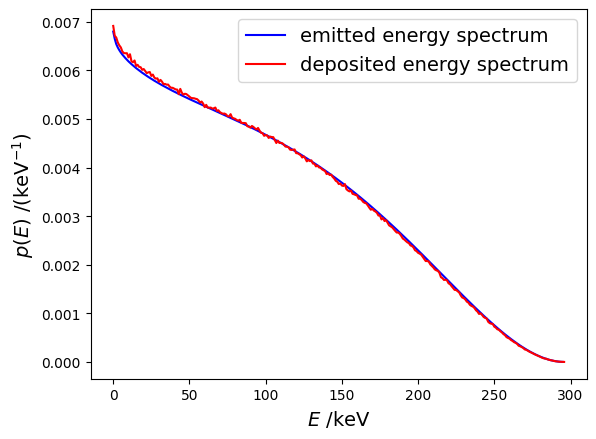

In [6]:
energy2, probability2 = td.TDCR_model_lib.readBetaSpectra(radionuclide)

plt.figure("Deposied energy spectrum")
plt.clf()
plt.plot(energy[:-1], probability,'-b', label="emitted energy spectrum")
plt.plot(energy2, probability2,'-r', label="deposited energy spectrum")
plt.legend(fontsize=14)
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'$p(E)$ /(keV$^{-1}$)', fontsize=14)

## Estimate deposited energy spectra for any volume of scintillator

This function uses interpolation in response kernels precalculated with MCNP6. 

Processing:   0%|          | 0/100000 [00:00<?, ? bins/s]

Processing: 100%|██████████| 100000/100000 [00:14<00:00, 6979.69 bins/s]



mean emitted E = 583.4145011392619 keV 329 328
mean deposited E = 520.1554799999999 keV 329 328



Processing: 100%|██████████| 100000/100000 [00:09<00:00, 10012.54 bins/s]


mean emitted E = 583.4145011392619 keV 329 328
mean deposited E = 541.2710800000001 keV 329 328



Text(0, 0.5, '$p(E)$ /(keV$^{-1}$)')

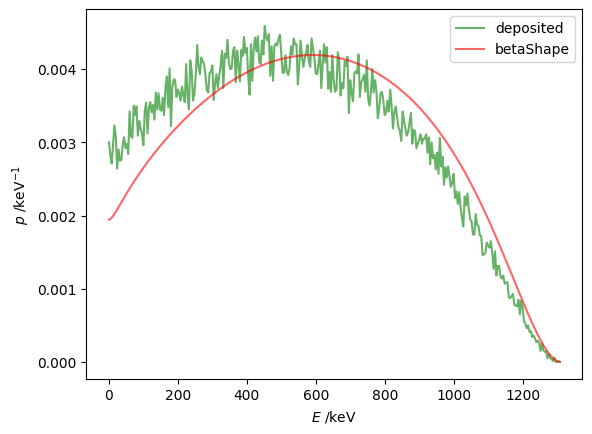

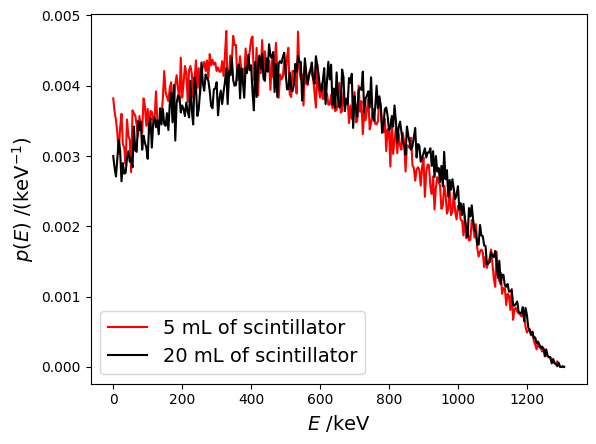

In [8]:
rad = "K-40"       # name of the nuclide
N = 100000        # number of MC sampling

V1 = 5            # volume of the scintillator in mL
energy3, probability3 = td.TDCR_model_lib.buildBetaSpectra(rad, V1, N, prt=False)
V2 = 20            # volume of the scintillator in mL
energy4, probability4 = td.TDCR_model_lib.buildBetaSpectra(rad, V2, N, prt=False)

plt.figure(f"Deposied energy spectrum of {rad}")
plt.clf()
plt.plot(energy3, probability3,'-r', label=f"{V1} mL of scintillator")
plt.plot(energy4, probability4,'-k', label=f"{V2} mL of scintillator")
plt.legend(fontsize=14)
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'$p(E)$ /(keV$^{-1}$)', fontsize=14)